In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.model_selection import KFold



In [3]:
df = pd.read_csv("E:/ml/ml_github/assign_8/Dataset.csv")
df.head()


,Math,Physics,Chemistry,Biology,Total_Science,Average_Science,English,Computer_Science,Sports_Score,Attendance_Percentage,Random_Noise_Feature,Final_Score_Regression,Performance_Level_Classification
0,81.963919,71.591250,65.428104,69.786180,288.769453,71.344844,63.564348,80.470009,59.504621,88.827011,-33.924737,63.165168,Medium
1,73.240525,67.894764,64.315432,68.430136,273.880857,67.563386,62.984703,57.450119,52.445246,90.367064,-15.274973,65.503878,Medium
2,76.775037,72.514786,74.408858,76.584987,300.283667,71.479630,65.997338,81.184728,57.414376,87.493450,-29.869053,75.776067,High
3,81.995615,83.690491,94.668737,88.066081,348.420923,86.445050,75.277242,81.548170,70.720976,75.287512,5.520902,83.577602,High
4,71.149583,58.190393,70.441232,59.457316,259.238524,66.275289,65.647724,74.078977,79.167850,84.222888,59.858927,69.100684,Medium


In [5]:
X = df.drop(['Final_Score_Regression','Performance_Level_Classification'],axis=1)

Y_reg = df['Final_Score_Regression']
Y_classify = df['Performance_Level_Classification']

le = LabelEncoder()
Y_classify_encoded=  le.fit_transform(Y_classify)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kfold= KFold(n_splits=5,shuffle=True,random_state=42)


The number of components chosen is  7


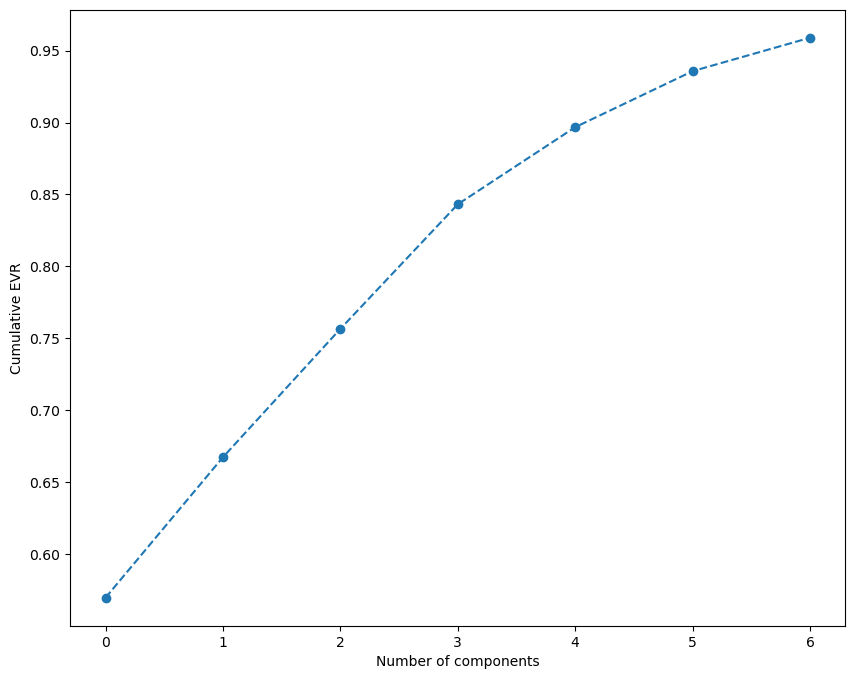

In [7]:
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA

pca = PCA(n_components=0.95) # Retaining EVR of 95%
X_pca = pca.fit_transform(X_scaled)

print("The number of components chosen is ",pca.n_components_)

plt.figure(figsize=(10,8))
plt.plot(np.cumsum(pca.explained_variance_ratio_),marker = 'o', linestyle= "--")
plt.xlabel("Number of components")
plt.ylabel("Cumulative EVR")
plt.show()



In [18]:
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.linear_model import LogisticRegression

kf = KFold(n_splits=5, shuffle=True, random_state=42)
param_grid_lr = {'C': [0.1, 1, 10, 100]}

grid_lr_no_pca = GridSearchCV(
    LogisticRegression(max_iter=1000), 
    param_grid_lr, cv=kf, 
    scoring=['accuracy', 'f1_macro'], refit='accuracy'
)
grid_lr_no_pca.fit(X_scaled, Y_classify_encoded)

print("LogReg Without PCA")
idx = grid_lr_no_pca.best_index_
print(f"Best Accuracy: {grid_lr_no_pca.best_score_:.4f}")
print(f"F1-Score: {grid_lr_no_pca.cv_results_['mean_test_f1_macro'][idx]:.4f}")

LogReg Without PCA
Best Accuracy: 0.7380
F1-Score: 0.7125


In [19]:
from sklearn.svm import SVC
param_grid_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}
grid_svm_no_pca = GridSearchCV(
    SVC(random_state=42), 
    param_grid_svm, 
    cv=kfold, 
    scoring=['accuracy', 'f1_macro'],
    refit='accuracy'
)
grid_svm_no_pca.fit(X_scaled, Y_classify_encoded)

print("SVM Without PCA")
print(f"Best Parameters: {grid_svm_no_pca.best_params_}")
print(f"Accuracy: {grid_svm_no_pca.best_score_:.4f}")
print(f"F1-Score: {grid_svm_no_pca.cv_results_['mean_test_f1_macro'][grid_svm_no_pca.best_index_]:.4f}")

SVM Without PCA
Best Parameters: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
Accuracy: 0.7440
F1-Score: 0.7173


In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
params_grid= {
    'C' :[0.01,0.1,1,10,100]
}

grid_lr_pca = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid=params_grid,
    cv=kfold,
    scoring=['accuracy', 'f1_macro'],
    refit='accuracy' 
)

grid_lr_pca.fit(X_pca, Y_classify_encoded)

print("Logistic Regression With PCA")
print(f"Best Parameters: {grid_lr_pca.best_params_}")
print(f"Accuracy: {grid_lr_pca.best_score_:.4f}")

f1_val = grid_lr_pca.cv_results_['mean_test_f1_macro'][grid_lr_pca.best_index_]
print(f"F1-Score: {f1_val:.4f}")

Logistic Regression With PCA
Best Parameters: {'C': 0.01}
Accuracy: 0.7460
F1-Score: 0.7113


In [21]:
from sklearn.svm import SVC
param_grid_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}
grid_svm_pca = GridSearchCV(
    SVC(random_state=42), 
    param_grid_svm, 
    cv=kfold, 
    scoring=['accuracy', 'f1_macro'],
    refit='accuracy' 
)
grid_svm_pca.fit(X_pca, Y_classify_encoded)

print("SVM With PCA")
print(f"Best Parameters: {grid_svm_pca.best_params_}")
print(f"Accuracy: {grid_svm_pca.best_score_:.4f}")
print(f"F1-Score: {grid_svm_pca.cv_results_['mean_test_f1_macro'][grid_svm_pca.best_index_]:.4f}")

SVM With PCA
Best Parameters: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
Accuracy: 0.7460
F1-Score: 0.7205


In [23]:
from sklearn.linear_model import LinearRegression
grid_lr_no_pca = GridSearchCV(
    LinearRegression(), {}, 
    cv=kf, scoring=['neg_mean_squared_error', 'r2'], refit='r2'
)
grid_lr_no_pca.fit(X_scaled, Y_reg)

print("Linear Regression Without PCA")
print(f"Avg MSE: {-grid_lr_no_pca.cv_results_['mean_test_neg_mean_squared_error'][0]:.4f}")
print(f"Avg R2 Score: {grid_lr_no_pca.best_score_:.4f}")

Linear Regression Without PCA
Avg MSE: 26.2338
Avg R2 Score: 0.7479


In [24]:
from sklearn.ensemble import RandomForestRegressor

param_grid_rf = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10, 20]
}

grid_rf_no_pca = GridSearchCV(
    RandomForestRegressor(random_state=42), 
    param_grid_rf, cv=kf, 
    scoring=['neg_mean_squared_error', 'r2'], refit='r2'
)
grid_rf_no_pca.fit(X_scaled, Y_reg)

print("Random Forest Without PCA")
idx_rf = grid_rf_no_pca.best_index_
print(f"Best Params: {grid_rf_no_pca.best_params_}")
print(f"Avg MSE: {-grid_rf_no_pca.cv_results_['mean_test_neg_mean_squared_error'][idx_rf]:.4f}")
print(f"Avg R2 Score: {grid_rf_no_pca.best_score_:.4f}")

--- Random Forest Without PCA ---
Best Params: {'max_depth': 10, 'n_estimators': 100}
Avg MSE: 28.9206
Avg R2 Score: 0.7225


In [25]:
grid_lr_pca = GridSearchCV(
    LinearRegression(), {}, 
    cv=kf, scoring=['neg_mean_squared_error', 'r2'], refit='r2'
)
grid_lr_pca.fit(X_pca, Y_reg)

print("Linear Regression With PCA")
print(f"Avg MSE: {-grid_lr_pca.cv_results_['mean_test_neg_mean_squared_error'][0]:.4f}")
print(f"Avg R2 Score: {grid_lr_pca.best_score_:.4f}")

Linear Regression With PCA
Avg MSE: 26.2251
Avg R2 Score: 0.7481


In [26]:
grid_rf_pca = GridSearchCV(
    RandomForestRegressor(random_state=42), 
    param_grid_rf, cv=kf, 
    scoring=['neg_mean_squared_error', 'r2'], refit='r2'
)
grid_rf_pca.fit(X_pca, Y_reg)

print("Random Forest With PCA")
idx_rf_pca = grid_rf_pca.best_index_
print(f"Best Params: {grid_rf_pca.best_params_}")
print(f"Avg MSE: {-grid_rf_pca.cv_results_['mean_test_neg_mean_squared_error'][idx_rf_pca]:.4f}")
print(f"Avg R2 Score: {grid_rf_pca.best_score_:.4f}")

Random Forest With PCA
Best Params: {'max_depth': 10, 'n_estimators': 100}
Avg MSE: 28.7573
Avg R2 Score: 0.7241
